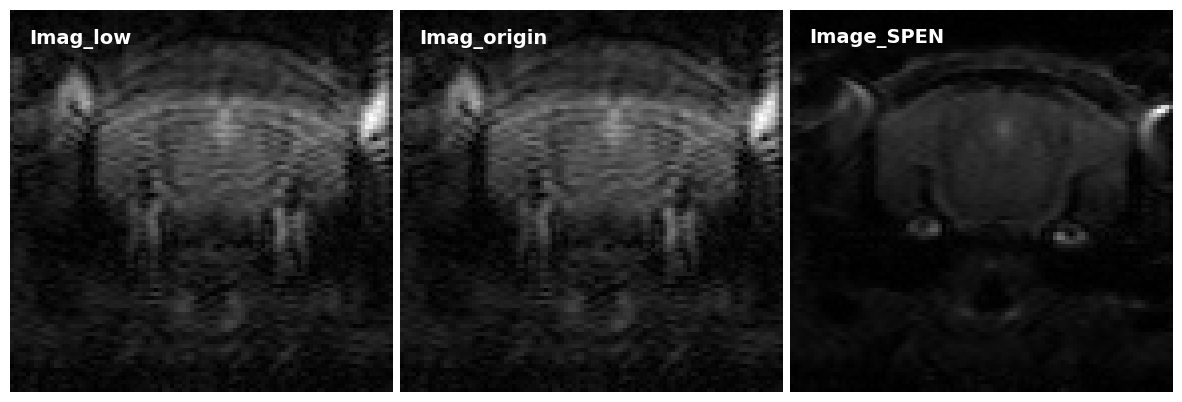

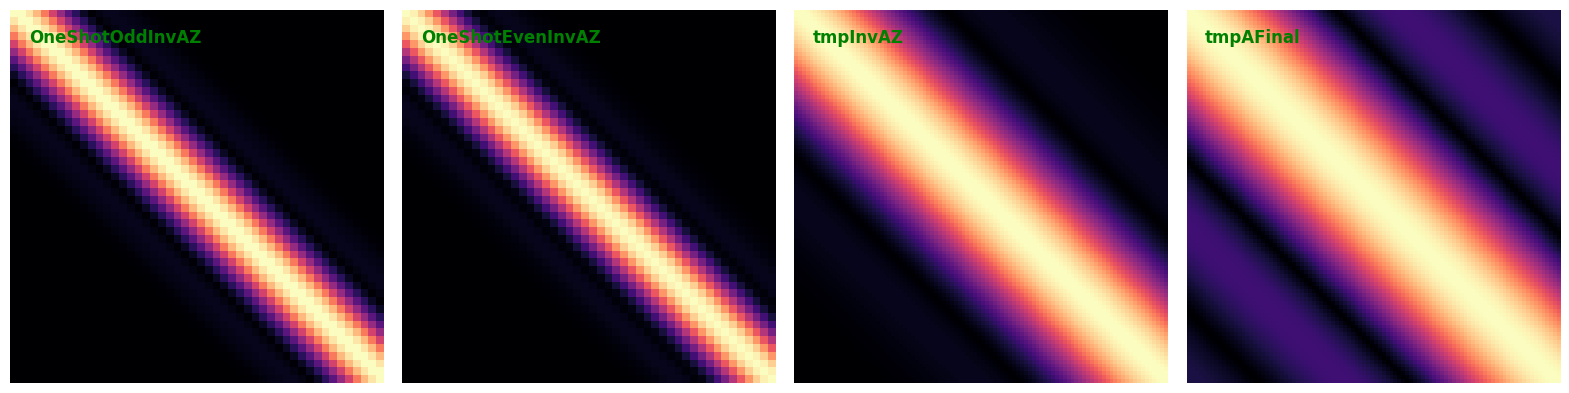

--- Check Dtypes (should be complex) ---
Imag_low: shape=(96, 96), dtype=complex128
Imag_origin: shape=(96, 96), dtype=complex64
Image_SPEN: shape=(96, 96), dtype=complex64


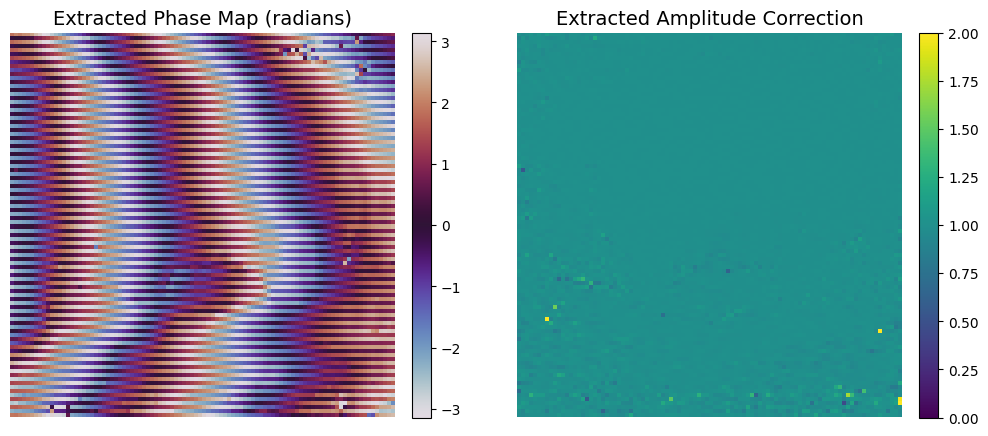

In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime
from spenpy.spen import spen
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as T
import torchvision.utils as vutils

# --- 1. Configuration ---
timestamp = datetime.now().strftime("%m%d%H%M")
MAT_FILE = '/home/data1/musong/workspace/2026/03/17/spen_matlab/export_data/pv360/ratbrain_SPEN_96_3.mat'
SAVE_DIR = os.path.join('log/0323_spen', timestamp)
os.makedirs(SAVE_DIR, exist_ok=True)

# --- 2. Load and Unpack Global Variables ---
mat = scipy.io.loadmat(MAT_FILE)

# Unpack the SPEN_AZ structure
spen_struct = mat['SPEN_AZ'][0, 0] 
OneShotOddInvAZ  = spen_struct['OneShotOddInvAZ']
OneShotEvenInvAZ = spen_struct['OneShotEvenInvAZ']
tmpInvAZ         = spen_struct['tmpInvAZ']
tmpAFinal        = spen_struct['tmpAFinal']

# --- 3. Figure 1: Main Image Comparison (1 x 3) ---
plot_keys = ['Imag_low', 'Imag_origin', 'Image_SPEN']
raw_data_list = [mat['Imag_low'], mat['Imag_origin'], mat['Image_SPEN']]

# This list will now hold COMPLEX rotated arrays
processed_arrays = [] 

fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5), gridspec_kw={'wspace': 0.02})

for i, raw_img in enumerate(raw_data_list):
    # Squeeze to remove single dimensions, but KEEP complex dtype
    img_complex = np.squeeze(raw_img)
    
    # Rotate first and second images (indices 0 and 1) by 180 degrees
    if i < 2:
        img_complex = np.rot90(img_complex, 2)
    
    # SAVE the complex data into the list
    processed_arrays.append(img_complex)
    
    # PLOT using magnitude (np.abs)
    axes1[i].imshow(np.abs(img_complex), cmap='gray')
    axes1[i].text(0.05, 0.95, plot_keys[i], color='white', fontweight='bold', 
                  fontsize=14, transform=axes1[i].transAxes, va='top')
    axes1[i].axis('off')

plt.savefig(os.path.join(SAVE_DIR, 'main_comparison_complex_saved.png'), bbox_inches='tight', dpi=300)
plt.show()

# --- 4. Figure 2: SPEN_AZ Variables (1 x 4) ---
az_keys = ['OneShotOddInvAZ', 'OneShotEvenInvAZ', 'tmpInvAZ', 'tmpAFinal']
az_data = [OneShotOddInvAZ, OneShotEvenInvAZ, tmpInvAZ, tmpAFinal]

fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5), gridspec_kw={'wspace': 0.05})

for j, raw_az in enumerate(az_data):
    # Squeeze and take magnitude for plotting
    img_az = np.abs(np.squeeze(raw_az))
    
    axes2[j].imshow(img_az, cmap='magma') 
    axes2[j].text(0.05, 0.95, az_keys[j], color='green', fontweight='bold', 
                  fontsize=12, transform=axes2[j].transAxes, va='top')
    axes2[j].axis('off')

plt.savefig(os.path.join(SAVE_DIR, 'spen_az_debug.png'), bbox_inches='tight', dpi=300)
plt.show()

# --- 5. Debug Verification ---
print("--- Check Dtypes (should be complex) ---")
for k, arr in zip(plot_keys, processed_arrays):
    print(f"{k}: shape={arr.shape}, dtype={arr.dtype}")

# --- 6. Extract and Plot Phase Map ---
# processed_arrays[0] is Imag_low
# processed_arrays[1] is Imag_origin

img_low = processed_arrays[0]
img_origin = processed_arrays[1]

# Calculate the phase difference map (using complex conjugate)
phase_map = np.angle(img_low * np.conj(img_origin))

# Calculate the amplitude correction map (adding small epsilon to prevent division by zero)
amp_map = np.abs(img_low) / np.abs(img_origin)

fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))

# Plot Phase Map ('twilight' is a cyclic colormap, perfect for phase -pi to pi)
im_phase = axes3[0].imshow(phase_map, cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes3[0].set_title('Extracted Phase Map (radians)', fontsize=14)
axes3[0].axis('off')
fig3.colorbar(im_phase, ax=axes3[0], fraction=0.046, pad=0.04)

# Plot Amplitude Map (clipping max at 2.0 to ignore noisy background spikes)
im_amp = axes3[1].imshow(amp_map, cmap='viridis', vmin=0, vmax=2)
axes3[1].set_title('Extracted Amplitude Correction', fontsize=14)
axes3[1].axis('off')
fig3.colorbar(im_amp, ax=axes3[1], fraction=0.046, pad=0.04)

plt.savefig(os.path.join(SAVE_DIR, 'extracted_phase_and_amp_maps.png'), bbox_inches='tight', dpi=300)
plt.show()


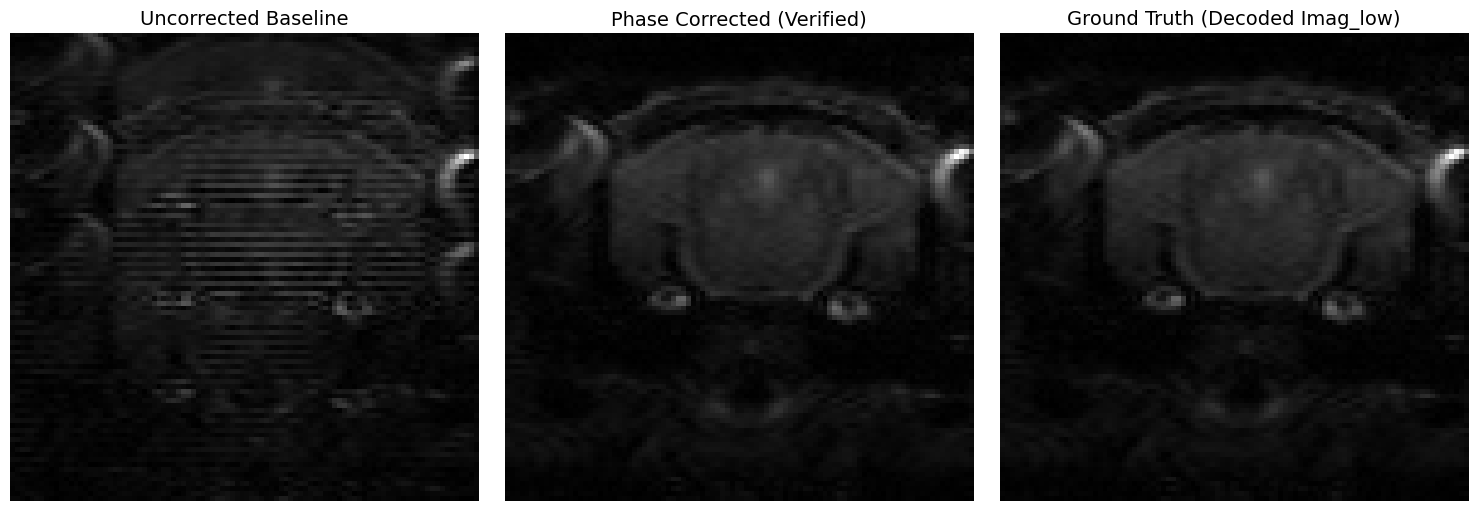

In [2]:
import torch
import matplotlib.pyplot as plt

# 1. Setup Matrices and Inputs
InvA, _ = spen(acq_point=(96, 96)).get_InvA()
input_tensor = torch.tensor(processed_arrays[1].copy(), dtype=torch.complex64)     # img_origin
img_low_tensor = torch.tensor(processed_arrays[0].copy(), dtype=torch.complex64)   # img_low
phase_map_tensor = torch.tensor(phase_map, dtype=torch.float32)

# 2. Get the Uncorrected Baseline
result_uncorrected = torch.matmul(InvA, input_tensor)

# 3. Apply Phase Correction (Directly to the even lines of the original data)
corrected_tensor = input_tensor.clone()
corrected_tensor *= torch.exp(1j * phase_map_tensor)

# 4. Decode the Corrected Signal
result_corrected = torch.matmul(InvA, corrected_tensor)

# 5. Decode the Ground Truth (img_low)
result_ground_truth = torch.matmul(InvA, img_low_tensor)

# --- 6. Plotting the 1x3 Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Uncorrected
axes[0].imshow(result_uncorrected.abs().cpu().numpy(), cmap='gray')
axes[0].set_title('Uncorrected Baseline', fontsize=14)
axes[0].axis('off')

# Plot 2: Our Phase-Corrected Version
axes[1].imshow(result_corrected.abs().cpu().numpy(), cmap='gray')
axes[1].set_title('Phase Corrected (Verified)', fontsize=14)
axes[1].axis('off')

# Plot 3: Ground Truth
axes[2].imshow(result_ground_truth.abs().cpu().numpy(), cmap='gray')
axes[2].set_title('Ground Truth (Decoded Imag_low)', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()